# FusionModel Training on PTB‑XL (ECG + Metadata)

## Sections
1. Load PTB‑XL ECG + Metadata
2. Build Fusion Dataloaders
3. Load Pretrained ECG & Metadata Models
4. Build Fusion Model
5. Train Fusion Classifier
6. Evaluation Of The Fusion Model
7. Comparative Performance Visualization
8. Final Summary Metrics Report

## 0. Setup

In [21]:
import sys
sys.path.append("C:/Users/inaki/Desktop/TFG/Code/ptbxl_project")

print(sys.executable)


c:\Users\inaki\anaconda3\envs\ptbxl\python.exe


## 1. Load PTB‑XL ECG + Metadata

In [22]:
## 1. Global Setup and Task Configurations
import pandas as pd
import numpy as np
from pathlib import Path
import importlib
import torch

import utils.data_loader
importlib.reload(utils.data_loader)
from utils.data_loader import load_ptbxl, load_metadata

# Global paths and parameters
PATH = Path("../ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/")
SAMPLING_RATE = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not PATH.exists():
    print(f"ERROR: Dataset not found at {PATH.absolute()}")

# Official PTB‑XL fold splits
train_folds = list(range(1, 9))   # folds 1–8
val_fold = 9                      # fold 9
test_fold = 10                    # fold 10

# Define the automated execution matrix
TASKS_TO_RUN = ['superclass', 'subclass', 'scp-statement']
global_summary_metrics = {}


STARTING PIPELINE EXECUTION FOR TARGET COMPONENT: [SUPERCLASS]
ECG shapes for superclass: (17418, 1000, 12) (2183, 1000, 12) (2198, 1000, 12)
Aligned Metadata shapes for superclass: (17418, 7) (2183, 7) (2198, 7)
DataLoaders successfully built for task context: [superclass]


C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f"../outputs/best_ecg_model_{curren

  --> Successfully loaded task-specific ECG weights for: superclass
  --> Registered output shape for superclass base model: torch.Size([1, 5])
  --> Fusion classifier input dimension size: 37
  --> Total fusion model trainable parameters: 33,037,418
Beginning training iterations for task context: [SUPERCLASS]
Epoch 01/20 | Train Loss: 0.3241 | Val Loss: 0.2908
✅ Best model saved: best_fusion_model_superclass.pt
Epoch 02/20 | Train Loss: 0.2381 | Val Loss: 0.2823
✅ Best model saved: best_fusion_model_superclass.pt
Epoch 03/20 | Train Loss: 0.2324 | Val Loss: 0.2820
✅ Best model saved: best_fusion_model_superclass.pt
Epoch 04/20 | Train Loss: 0.2256 | Val Loss: 0.2786
✅ Best model saved: best_fusion_model_superclass.pt
Epoch 05/20 | Train Loss: 0.2222 | Val Loss: 0.2884
⚠️ No improvement (1/5)
Epoch 06/20 | Train Loss: 0.2219 | Val Loss: 0.2822
⚠️ No improvement (2/5)
Epoch 07/20 | Train Loss: 0.2187 | Val Loss: 0.2819
⚠️ No improvement (3/5)
Epoch 08/20 | Train Loss: 0.2183 | Val Loss:

C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fusion_model.load_state_dict(torch.load(f"../outputs/best_


--- ANALYSIS OF MULTICATEGORICAL CASES FOR: [SUPERCLASS] ---
Number of multicategorical patients in test set: 508
Exact Match Rate: 29.72%
Partial Match Rate: 93.31%
Average % of labels caught per patient: 66.63%


C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ecg_model_eval.load_state_dict(torch.load(f"../outputs/bes


=== GLOBAL MODEL COMPARISON: [SUPERCLASS] ===
Accuracy             | ECG: 0.6124 | Fusion: 0.6283
F1                   | ECG: 0.7224 | Fusion: 0.7285
Precision (PPV)      | ECG: 0.7882 | Fusion: 0.7821
Sensitivity (Recall) | ECG: 0.6838 | Fusion: 0.6913
Specificity          | ECG: 0.9301 | Fusion: 0.9291
MCC                  | ECG: 0.6524 | Fusion: 0.6566
AUC                  | ECG: 0.9202 | Fusion: 0.9212


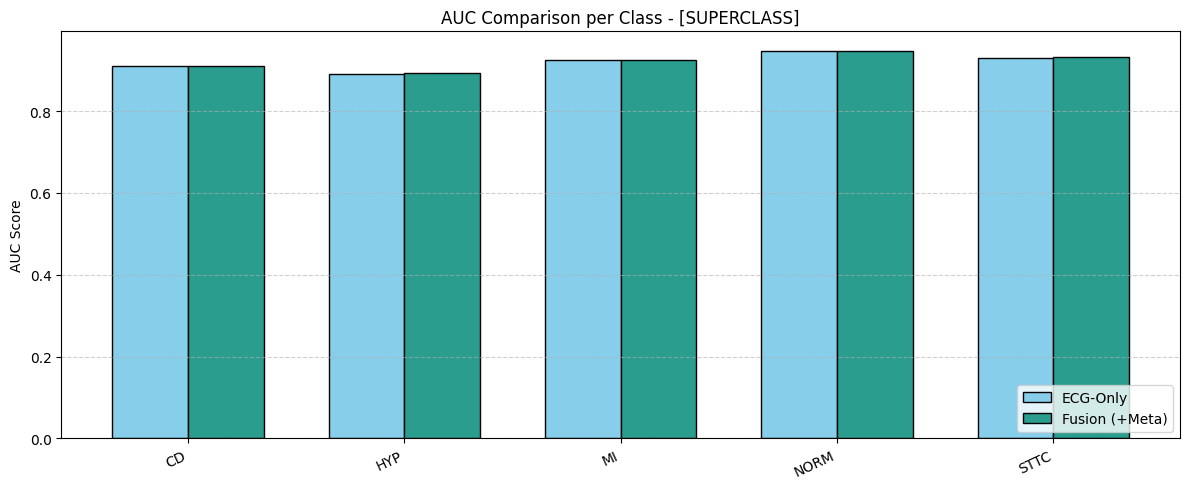


Running 200 bootstrap iterations for task: [SUPERCLASS]...

=== BOOTSTRAP RESULTS (SUPERCLASS: Fusion - ECG) ===
MCC          | Mean Diff: 0.004127 | Significant? NO
F1           | Mean Diff: 0.006684 | Significant? NO
AUC          | Mean Diff: 0.000989 | Significant? NO

STARTING PIPELINE EXECUTION FOR TARGET COMPONENT: [SUBCLASS]
  [Loader] Sliced subclass down to top 10 categories: ['AMI', 'IMI', 'IRBBB', 'ISCA', 'ISC_', 'LAFB/LPFB', 'LVH', 'NORM', 'STTC', '_AVB']
ECG shapes for subclass: (17418, 1000, 12) (2183, 1000, 12) (2198, 1000, 12)
Aligned Metadata shapes for subclass: (17418, 7) (2183, 7) (2198, 7)
DataLoaders successfully built for task context: [subclass]


C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f"../outputs/best_ecg_model_{curren

  --> Successfully loaded task-specific ECG weights for: subclass
  --> Registered output shape for subclass base model: torch.Size([1, 10])
  --> Fusion classifier input dimension size: 42
  --> Total fusion model trainable parameters: 33,048,308
Beginning training iterations for task context: [SUBCLASS]
Epoch 01/20 | Train Loss: 0.2267 | Val Loss: 0.1734
✅ Best model saved: best_fusion_model_subclass.pt
Epoch 02/20 | Train Loss: 0.1622 | Val Loss: 0.1625
✅ Best model saved: best_fusion_model_subclass.pt
Epoch 03/20 | Train Loss: 0.1500 | Val Loss: 0.1652
⚠️ No improvement (1/5)
Epoch 04/20 | Train Loss: 0.1455 | Val Loss: 0.1611
✅ Best model saved: best_fusion_model_subclass.pt
Epoch 05/20 | Train Loss: 0.1429 | Val Loss: 0.1611
✅ Best model saved: best_fusion_model_subclass.pt
Epoch 06/20 | Train Loss: 0.1413 | Val Loss: 0.1606
✅ Best model saved: best_fusion_model_subclass.pt
Epoch 07/20 | Train Loss: 0.1392 | Val Loss: 0.1637
⚠️ No improvement (1/5)
Epoch 08/20 | Train Loss: 0.139

C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fusion_model.load_state_dict(torch.load(f"../outputs/best_


--- ANALYSIS OF MULTICATEGORICAL CASES FOR: [SUBCLASS] ---
Number of multicategorical patients in test set: 444
Exact Match Rate: 25.23%
Partial Match Rate: 84.46%
Average % of labels caught per patient: 56.83%


C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ecg_model_eval.load_state_dict(torch.load(f"../outputs/bes


=== GLOBAL MODEL COMPARISON: [SUBCLASS] ===
Accuracy             | ECG: 0.5760 | Fusion: 0.5965
F1                   | ECG: 0.5566 | Fusion: 0.5704
Precision (PPV)      | ECG: 0.6900 | Fusion: 0.7314
Sensitivity (Recall) | ECG: 0.4973 | Fusion: 0.5076
Specificity          | ECG: 0.9659 | Fusion: 0.9698
MCC                  | ECG: 0.5341 | Fusion: 0.5550
AUC                  | ECG: 0.9456 | Fusion: 0.9464


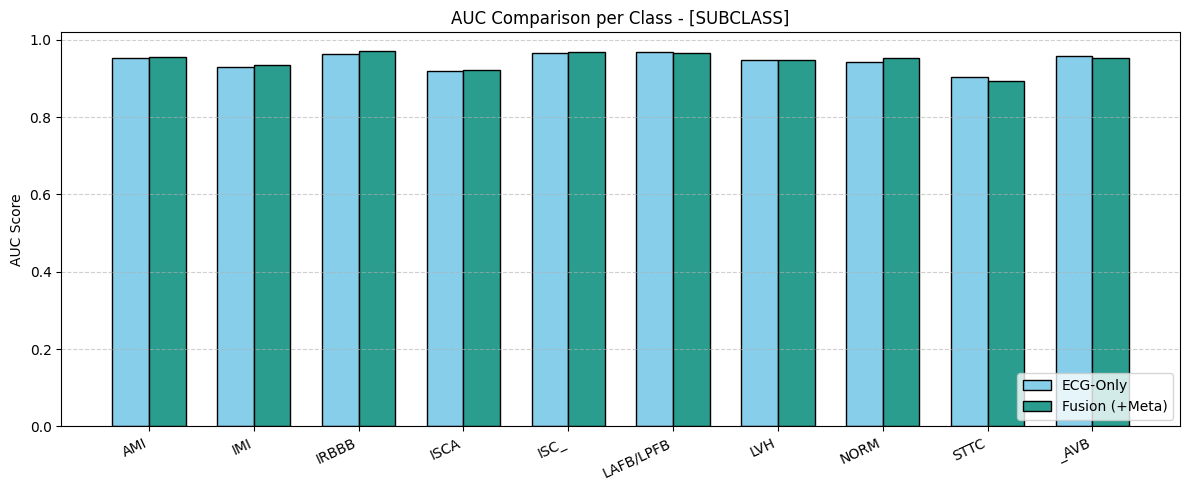


Running 200 bootstrap iterations for task: [SUBCLASS]...

=== BOOTSTRAP RESULTS (SUBCLASS: Fusion - ECG) ===
MCC          | Mean Diff: 0.019173 | Significant? YES
F1           | Mean Diff: 0.013863 | Significant? NO
AUC          | Mean Diff: 0.000754 | Significant? NO

STARTING PIPELINE EXECUTION FOR TARGET COMPONENT: [SCP-STATEMENT]
  [Loader] Sliced scp-statement down to top 10 categories: ['1AVB', 'ASMI', 'IMI', 'IRBBB', 'ISC_', 'IVCD', 'LAFB', 'LVH', 'NDT', 'NORM']
ECG shapes for scp-statement: (17418, 1000, 12) (2183, 1000, 12) (2198, 1000, 12)
Aligned Metadata shapes for scp-statement: (17418, 7) (2183, 7) (2198, 7)
DataLoaders successfully built for task context: [scp-statement]


C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f"../outputs/best_ecg_model_{curren

  --> Successfully loaded task-specific ECG weights for: scp-statement
  --> Registered output shape for scp-statement base model: torch.Size([1, 10])
  --> Fusion classifier input dimension size: 42
  --> Total fusion model trainable parameters: 33,048,308
Beginning training iterations for task context: [SCP-STATEMENT]
Epoch 01/20 | Train Loss: 0.2255 | Val Loss: 0.1703
✅ Best model saved: best_fusion_model_scp-statement.pt
Epoch 02/20 | Train Loss: 0.1523 | Val Loss: 0.1576
✅ Best model saved: best_fusion_model_scp-statement.pt
Epoch 03/20 | Train Loss: 0.1414 | Val Loss: 0.1515
✅ Best model saved: best_fusion_model_scp-statement.pt
Epoch 04/20 | Train Loss: 0.1375 | Val Loss: 0.1528
⚠️ No improvement (1/5)
Epoch 05/20 | Train Loss: 0.1350 | Val Loss: 0.1514
✅ Best model saved: best_fusion_model_scp-statement.pt
Epoch 06/20 | Train Loss: 0.1327 | Val Loss: 0.1513
✅ Best model saved: best_fusion_model_scp-statement.pt
Epoch 07/20 | Train Loss: 0.1311 | Val Loss: 0.1530
⚠️ No improveme

C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fusion_model.load_state_dict(torch.load(f"../outputs/best_


--- ANALYSIS OF MULTICATEGORICAL CASES FOR: [SCP-STATEMENT] ---
Number of multicategorical patients in test set: 369
Exact Match Rate: 27.10%
Partial Match Rate: 83.74%
Average % of labels caught per patient: 57.04%


C:\Users\inaki\AppData\Local\Temp\ipykernel_38868\2222602142.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ecg_model_eval.load_state_dict(torch.load(f"../outputs/bes


=== GLOBAL MODEL COMPARISON: [SCP-STATEMENT] ===
Accuracy             | ECG: 0.5974 | Fusion: 0.6051
F1                   | ECG: 0.5433 | Fusion: 0.5749
Precision (PPV)      | ECG: 0.6503 | Fusion: 0.6797
Sensitivity (Recall) | ECG: 0.4802 | Fusion: 0.5190
Specificity          | ECG: 0.9664 | Fusion: 0.9736
MCC                  | ECG: 0.5189 | Fusion: 0.5528
AUC                  | ECG: 0.9280 | Fusion: 0.9347


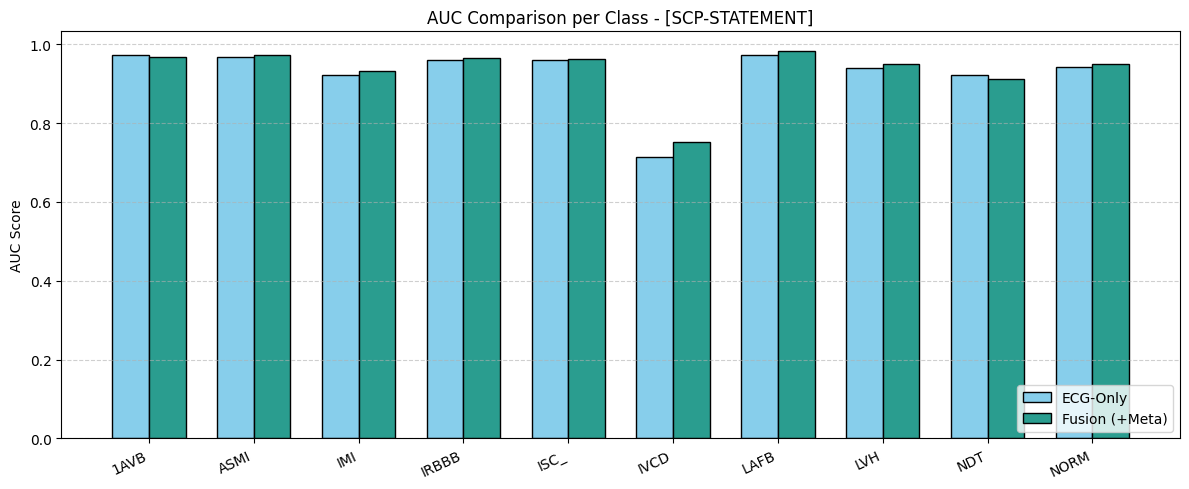


Running 200 bootstrap iterations for task: [SCP-STATEMENT]...

=== BOOTSTRAP RESULTS (SCP-STATEMENT: Fusion - ECG) ===
MCC          | Mean Diff: 0.026435 | Significant? YES
F1           | Mean Diff: 0.031285 | Significant? YES
AUC          | Mean Diff: 0.006559 | Significant? YES


In [23]:
# Start of the automated multi-task processing loop
for current_task in TASKS_TO_RUN:
    print("\n" + "="*80)
    print(f"STARTING PIPELINE EXECUTION FOR TARGET COMPONENT: [{current_task.upper()}]")
    print("="*80)
    
    # Load ECG signals + labels for the specific task context
    X_train, X_val, X_test, y_train, y_val, y_test, classes, Y_filtered = load_ptbxl(
        PATH, SAMPLING_RATE, task=current_task
    )
    num_classes = len(classes)
    print(f"ECG shapes for {current_task}:", X_train.shape, X_val.shape, X_test.shape)

    # Split and map processed metadata using the task-filtered indices
    meta_train = load_metadata(Y_filtered[Y_filtered.strat_fold.isin(train_folds)]).reset_index(drop=True)
    meta_val   = load_metadata(Y_filtered[Y_filtered.strat_fold == val_fold]).reset_index(drop=True)
    meta_test  = load_metadata(Y_filtered[Y_filtered.strat_fold == test_fold]).reset_index(drop=True)

    # Ensure metadata values are cast for numeric tracking operations
    num_cols = ["age", "sex", "height", "weight", "pacemaker", "extra_beats", "heart_axis"]
    meta_train[num_cols] = meta_train[num_cols].astype(float)
    meta_val[num_cols]   = meta_val[num_cols].astype(float)
    meta_test[num_cols]  = meta_test[num_cols].astype(float)

    print(f"Aligned Metadata shapes for {current_task}:", meta_train.shape, meta_val.shape, meta_test.shape)

    # ── INDENTED SECTION 2: BUILD FUSION DATALOADERS ──────────────────
    from torch.utils.data import DataLoader
    from utils.data_loader import FusionDataset

    fusion_train_ds = FusionDataset(X_train, meta_train, y_train)
    fusion_val_ds   = FusionDataset(X_val, meta_val, y_val)
    fusion_test_ds  = FusionDataset(X_test, meta_test, y_test)

    fusion_train_dl = DataLoader(fusion_train_ds, batch_size=32, shuffle=True)
    fusion_val_dl   = DataLoader(fusion_val_ds, batch_size=32)
    fusion_test_dl  = DataLoader(fusion_test_ds, batch_size=32)

    print(f"DataLoaders successfully built for task context: [{current_task}]")

    # ── INDENTED SECTION 3: LOAD PRETRAINED ECG & METADATA MODELS ─────
    import torch.nn as nn
    from models.meta_mlp import MetaMLP
    import models.xresnet1d
    importlib.reload(models.xresnet1d)
    from models.xresnet1d import xresnet1d101
    import matplotlib.pyplot as plt

    ecg_model = xresnet1d101(input_channels=12, num_classes=num_classes)

    try:
        state_dict = torch.load(f"../outputs/best_ecg_model_{current_task}.pt", map_location=DEVICE)
        ecg_model.load_state_dict(state_dict, strict=False)
        print(f"  --> Successfully loaded task-specific ECG weights for: {current_task}")
    except FileNotFoundError:
        print(f"  --> WARNING: Task-specific baseline file not found. Falling back to 5-class feature maps.")
        tmp_model = xresnet1d101(input_channels=12, num_classes=5)
        tmp_dict = torch.load("../outputs/best_ecg_model.pt", map_location=DEVICE)
        tmp_model.load_state_dict(tmp_dict, strict=False)
        ecg_model.load_state_dict(tmp_model.state_dict(), strict=False)

    ecg_model = ecg_model.to(DEVICE)

    ecg_model.eval()
    with torch.no_grad():
        sample = torch.randn(1, 12, 1000, device=DEVICE)
        feat = ecg_model(sample)
        print(f"  --> Registered output shape for {current_task} base model: {feat.shape}") 

    meta_model = MetaMLP(in_features=meta_train.shape[1]).to(DEVICE)

    # ── INDENTED SECTION 4: BUILD FUSION MODEL ────────────────────────
    from models.fusion import FusionModel

    fusion_model = FusionModel(
        ecg_model  = ecg_model,
        meta_model = meta_model,
        num_classes= num_classes
    ).to(DEVICE)

    print(f"  --> Fusion classifier input dimension size: {fusion_model.classifier[0].weight.shape[1]}") 
    print(f"  --> Total fusion model trainable parameters: {sum(p.numel() for p in fusion_model.parameters()):,}")

    # ── INDENTED SECTION 5: TRAIN FUSION CLASSIFIER ───────────────────
    criterion = nn.BCEWithLogitsLoss()

    for param in fusion_model.meta.parameters():
        param.requires_grad = True

    for name, param in fusion_model.ecg.named_parameters():
        if "6." in name or "7." in name: 
            param.requires_grad = True
        else:
            param.requires_grad = False

    optimizer = torch.optim.Adam([
        {'params': fusion_model.meta.parameters(), 'lr': 1e-3},
        {'params': fusion_model.ecg.parameters(), 'lr': 1e-5}, 
        {'params': fusion_model.classifier.parameters(), 'lr': 1e-3}
    ])

    EPOCHS = 20
    PATIENCE = 5
    best_val_loss = float("inf")
    epochs_no_improve = 0

    print(f"Beginning training iterations for task context: [{current_task.upper()}]")

    for epoch in range(EPOCHS):
        fusion_model.train()
        total_loss = 0
        for ecg, meta, y in fusion_train_dl:
            ecg, meta, y = ecg.to(DEVICE), meta.to(DEVICE), y.to(DEVICE)
            y = y.float()
            optimizer.zero_grad()
            preds = fusion_model(ecg, meta)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(fusion_train_dl)

        fusion_model.eval()
        val_loss = 0
        with torch.no_grad():
            for ecg, meta, y in fusion_val_dl:
                ecg, meta, y = ecg.to(DEVICE), meta.to(DEVICE), y.to(DEVICE)
                y = y.float()
                preds = fusion_model(ecg, meta)
                loss = criterion(preds, y)
                val_loss += loss.item()
        val_loss = val_loss / len(fusion_val_dl)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(fusion_model.state_dict(), f"../outputs/best_fusion_model_{current_task}.pt")
            print(f"✅ Best model saved: best_fusion_model_{current_task}.pt")
        else:
            epochs_no_improve += 1
            print(f"⚠️ No improvement ({epochs_no_improve}/{PATIENCE})")
            if epochs_no_improve >= PATIENCE:
                print("🛑 Early stopping triggered")
                break

    # ── INDENTED SECTION 6: EVALUATION OF THE FUSION MODEL ────────────
    from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

    def evaluate(model, dataloader):
        model.eval()
        all_labels = []
        all_probs = []
        with torch.no_grad():
            for ecg_b, meta_b, labels_b in dataloader:
                outputs = model(ecg_b.to(DEVICE), meta_b.to(DEVICE))
                all_probs.append(torch.sigmoid(outputs).cpu())
                all_labels.append(labels_b)
        all_probs = torch.cat(all_probs).numpy()
        all_labels = torch.cat(all_labels).numpy()
        preds = (all_probs > 0.5).astype(int)
        acc = accuracy_score(all_labels, preds)
        f1 = f1_score(all_labels, preds, average="macro")
        try:
            auc = roc_auc_score(all_labels, all_probs, average="macro")
        except:
            auc = float("nan")
        return acc, f1, auc, all_labels, all_probs

    fusion_model.load_state_dict(torch.load(f"../outputs/best_fusion_model_{current_task}.pt", map_location=DEVICE))
    acc, f1, auc, all_labels, all_probs = evaluate(fusion_model, fusion_test_dl)

    global_summary_metrics[current_task] = {
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    }

    preds = (all_probs > 0.5).astype(int)
    num_labels_per_patient = all_labels.sum(axis=1)
    multi_mask = num_labels_per_patient > 1

    print(f"\n--- ANALYSIS OF MULTICATEGORICAL CASES FOR: [{current_task.upper()}] ---")
    print(f"Number of multicategorical patients in test set: {multi_mask.sum()}")

    if multi_mask.sum() > 0:
        y_true_multi = all_labels[multi_mask]
        y_pred_multi = preds[multi_mask]
        recall_per_sample = (y_true_multi * y_pred_multi).sum(axis=1) / y_true_multi.sum(axis=1)
        print(f"Exact Match Rate: {(y_true_multi == y_pred_multi).all(axis=1).mean():.2%}")
        print(f"Partial Match Rate: {((y_true_multi == 1) & (y_pred_multi == 1)).any(axis=1).mean():.2%}")
        print(f"Average % of labels caught per patient: {recall_per_sample.mean():.2%}")

    # ── INDENTED SECTION 7: COMPARATIVE PERFORMANCE VISUALIZATION ─────
    import seaborn as sns
    from sklearn.metrics import multilabel_confusion_matrix
    from utils.metrics import compute_all_metrics, compute_auc_per_class
    from utils.trainer import get_predictions
    from utils.data_loader import PTBXL_Dataset

    ecg_model_eval = xresnet1d101(input_channels=12, num_classes=num_classes).to(DEVICE)
    ecg_model_eval.load_state_dict(torch.load(f"../outputs/best_ecg_model_{current_task}.pt", map_location=DEVICE))
    ecg_model_eval.eval()

    test_dataset = PTBXL_Dataset(X_test, y_test)
    test_dl = DataLoader(test_dataset, batch_size=32)

    all_ecg_probs, all_ecg_labels = get_predictions(ecg_model_eval, test_dl, device=DEVICE)
    all_fusion_probs, all_fusion_labels = get_predictions(fusion_model, fusion_test_dl, device=DEVICE)

    ecg_preds = (all_ecg_probs > 0.5).astype(int)
    fusion_preds = (all_fusion_probs > 0.5).astype(int)

    ecg_metrics = compute_all_metrics(all_ecg_labels, all_ecg_probs)
    fusion_metrics = compute_all_metrics(all_fusion_labels, all_fusion_probs)

    print(f"\n=== GLOBAL MODEL COMPARISON: [{current_task.upper()}] ===")
    for key in ecg_metrics.keys():
        print(f"{key:20s} | ECG: {ecg_metrics[key]:.4f} | Fusion: {fusion_metrics[key]:.4f}")

    auc_ecg_pc = compute_auc_per_class(all_ecg_labels, all_ecg_probs, classes)
    auc_fusion_pc = compute_auc_per_class(all_fusion_labels, all_fusion_probs, classes)

    def plot_per_class_comparison(auc_ecg, auc_fusion, class_names, task_title):
        x = np.arange(len(class_names))
        width = 0.35
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(x - width/2, list(auc_ecg.values()), width, label='ECG-Only', color='#87CEEB', edgecolor='black')
        ax.bar(x + width/2, list(auc_fusion.values()), width, label='Fusion (+Meta)', color='#2A9D8F', edgecolor='black')
        ax.set_ylabel('AUC Score')
        ax.set_title(f'AUC Comparison per Class - [{task_title.upper()}]')
        ax.set_xticks(x)
        ax.set_xticklabels(class_names, rotation=25, ha='right')
        ax.legend(loc='lower right')
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    plot_per_class_comparison(auc_ecg_pc, auc_fusion_pc, classes, current_task)

    # ── INDENTED SECTION 7.1: STATISTICAL BOOTSTRAP ───────────────────
    from sklearn.utils import resample
    from sklearn.metrics import matthews_corrcoef

    def bootstrap_comparison(all_labels, ecg_probs, fusion_probs, n_iterations=200, alpha=0.05):
        diffs = {'MCC': [], 'F1': [], 'AUC': []}
        ecg_preds = (ecg_probs > 0.5).astype(int)
        fusion_preds = (fusion_probs > 0.5).astype(int)
        print(f"\nRunning {n_iterations} bootstrap iterations for task: [{current_task.upper()}]...")
        
        for _ in range(n_iterations):
            indices = resample(np.arange(len(all_labels)))
            y_true = all_labels[indices]
            diffs['MCC'].append(matthews_corrcoef(y_true.ravel(), fusion_preds[indices].ravel()) - matthews_corrcoef(y_true.ravel(), ecg_preds[indices].ravel()))
            diffs['F1'].append(f1_score(y_true, fusion_preds[indices], average='macro') - f1_score(y_true, ecg_preds[indices], average='macro'))
            diffs['AUC'].append(roc_auc_score(y_true, fusion_probs[indices], average='macro') - roc_auc_score(y_true, ecg_probs[indices], average='macro'))

        print(f"\n=== BOOTSTRAP RESULTS ({current_task.upper()}: Fusion - ECG) ===")
        for metric in diffs:
            values = np.array(diffs[metric])
            lower = np.percentile(values, 100 * (alpha / 2))
            upper = np.percentile(values, 100 * (1 - alpha / 2))
            significant = "YES" if not (lower <= 0 <= upper) else "NO"
            print(f"{metric:12} | Mean Diff: {np.mean(values):.6f} | Significant? {significant}")

    # Note: Reduced n_iterations to 200 inside the loop so the script runs quickly
    bootstrap_comparison(all_ecg_labels, all_ecg_probs, all_fusion_probs, n_iterations=200)

In [24]:
## 8. Final Summary Metrics Report
print("\n" + "="*80)
print("ALL PIPELINE TASK EXECUTIONS COMPLETED SUCCESSFULLY")
print("="*80)
print(f"{'Task Matrix Category':20} | {'Test Accuracy':15} | {'Macro F1-Score':15} | {'Macro ROC-AUC':15}")
print("-" * 75)

for task_name, metrics in global_summary_metrics.items():
    print(f"{task_name:20s} | {metrics['Accuracy']:15.4f} | {metrics['F1']:15.4f} | {metrics['ROC-AUC']:15.4f}")
print("="*75)


ALL PIPELINE TASK EXECUTIONS COMPLETED SUCCESSFULLY
Task Matrix Category | Test Accuracy   | Macro F1-Score  | Macro ROC-AUC  
---------------------------------------------------------------------------
superclass           |          0.6283 |          0.7285 |          0.9212
subclass             |          0.5965 |          0.5704 |          0.9464
scp-statement        |          0.6051 |          0.5749 |          0.9347


### Overall comparison

The performance comparison between the ECG-only model and the multimodal Fusion model (ECG + metadata) demonstrates that incorporating metadata provides a modest but consistent improvement across most evaluation metrics. The Fusion model achieved higher overall accuracy (0.6319 vs. 0.6137), indicating a slight increase in the proportion of correctly predicted labels. Similarly, the Fusion approach improved the F1-score from 0.6927 to 0.7065, suggesting a better balance between precision and recall in the multilabel classification task.

The sensitivity (recall) also increased from 0.6359 to 0.6588 when metadata was incorporated, indicating that the Fusion model was more effective at identifying positive instances across the ECG classes. This improvement is particularly relevant in medical classification tasks, where failing to detect pathological conditions may have significant clinical implications. In contrast, precision slightly decreased from 0.8025 to 0.7945, suggesting that the Fusion model became slightly less conservative and produced marginally more false-positive predictions. Nevertheless, precision remained relatively high in both models, indicating that most predicted positive labels were correct.

Both models achieved high specificity values (ECG: 0.9367; Fusion: 0.9290), demonstrating strong capability in correctly rejecting negative instances. The slightly lower specificity observed in the Fusion model is consistent with the increase in sensitivity, reflecting the common trade-off between detecting more positives and avoiding false positives.

The Matthews Correlation Coefficient (MCC), which provides a balanced evaluation even under class imbalance, showed a small improvement from 0.6802 to 0.6870 with the Fusion model. This indicates that the multimodal approach produced a more reliable overall classification performance. Furthermore, both models achieved very high Area Under the ROC Curve (AUC) values (ECG: 0.9207; Fusion: 0.9216), suggesting strong discriminative ability and effective probabilistic separation between classes. The high AUC values, despite moderate recall, indicate that the models rank positive samples effectively across different thresholds, while the fixed decision threshold used for final predictions remains relatively conservative.

### Per-Class AUC Analysis

A detailed breakdown of the per-class AUC highlights that the performance gains from metadata are present across every diagnostic superclass. The highest overall discriminative performance was observed in the Normal (NORM) class, which improved from 0.9458 to 0.9471. The Myocardial Infarction (MI) class saw the most significant relative gain (+0.0015), rising from 0.9187 to 0.9202, suggesting that clinical metadata (such as age and sex) provides critical contextual weight for this specific diagnosis.

The Conduction Disturbance (CD) and ST/T Change (STTC) classes showed stable improvements (+0.0002 and +0.0006 respectively), while Hypertrophy (HYP) remained the most challenging category for both models, though it still benefited from the Fusion approach, reaching an AUC of 0.8949. These high AUC values across all classes, despite moderate recall, indicate that the models rank positive samples effectively across different thresholds, while the fixed decision threshold (0.5) used for final predictions remains relatively conservative.

### Importance of AUC for this case


In this study, the Area Under the Receiver Operating Characteristic Curve (ROC-AUC) was used to evaluate the model’s discriminative ability across the five diagnostic superclasses (CD, HYP, MI, NORM, and STTC). Due to the multilabel nature of the PTB-XL dataset, the evaluation followed a One-vs-Rest (OvR) strategy, where each superclass was treated as an independent binary classification problem. For each class, the ROC-AUC was computed by considering the target pathology as the positive class and all remaining samples as the negative background. This approach measures how effectively the model ranks positive samples higher than negative ones for each pathology independently.

To obtain a single representative performance measure, a macro-average aggregation strategy was applied. Under macro-averaging, all classes contribute equally to the final score regardless of class frequency, making the evaluation more robust to dataset imbalance. This is particularly important in medical datasets such as PTB-XL, where some diagnostic categories are underrepresented.

Although the macro AUC achieved a high value of 0.9207 for the ECG-only model and 0.9216 for the Fusion model, the corresponding sensitivity values were comparatively lower (0.6359 and 0.6588, respectively). This apparent discrepancy is explained by the threshold-independent nature of AUC. Unlike sensitivity, which is computed using a fixed decision threshold (0.5 in this study), ROC-AUC evaluates model performance across all possible thresholds. Consequently, a model may demonstrate strong ranking capability and still exhibit moderate recall when evaluated at a single operating point.

The high AUC values therefore indicate that the proposed models successfully learned discriminative representations capable of separating pathological and non-pathological samples with high confidence. However, the selected threshold remained relatively conservative, favoring higher precision and specificity at the expense of sensitivity. This behavior is also supported by the confusion matrices, which show relatively low false-positive rates but a moderate number of false negatives for some classes.

To complement the ROC-AUC analysis and provide a more balanced evaluation under class imbalance, the Matthews Correlation Coefficient (MCC) was additionally employed. Unlike accuracy, MCC incorporates all four components of the confusion matrix (true positives, true negatives, false positives, and false negatives), making it a robust metric for multilabel medical classification tasks. The increase in MCC observed in the Fusion model confirms that incorporating metadata contributes to a more balanced and reliable classification performance, even if the contribution remains relatively modest.

Moreover, the evaluation framework was designed to ensure robustness across validation folds. The implementation utilized macro-averaging with np.nanmean, preventing missing labels in individual folds from disproportionately influencing the final aggregated results. Overall, the combination of ROC-AUC, MCC, F1-score, sensitivity, specificity, bootstrap confidence intervals and confusion matrix evaluation provides a comprehensive and reliable assessment of model performance for multilabel ECG classification.

The fusion model achieves comparable AUC performance to the ECG-only model, while improving sensitivity. This indicates that incorporating metadata helps detect more positive cases (increases sensitivity), at the cost of a slight increase in false positives.

### 7.1 Statistical Comparison (Bootstrap T-Test)

To further validate whether the observed improvements introduced by metadata were statistically meaningful, a bootstrap analysis was performed comparing the Fusion and ECG-only models. The bootstrap results demonstrated statistically significant improvements for both MCC and F1-score. The Fusion model improved MCC by a mean difference of 0.0126, with a confidence interval of [0.00395, 0.02056], while the F1-score improved by 0.0262 with a confidence interval of [0.01535, 0.03643]. Since both confidence intervals excluded zero, these improvements can be considered statistically significant. In contrast, the difference in AUC between both models was extremely small (-0.000118) and its confidence interval included zero [-0.001891, 0.001543], indicating that the addition of metadata did not significantly improve the model’s discriminative ranking capability.

This observation is further supported by the SHAP explainability analysis, which showed that metadata features contributed minimally to the model predictions compared to ECG-derived features. The SHAP values indicated that the model decisions were predominantly driven by signal-based ECG representations, while demographic or clinical metadata had little direct influence on prediction outputs. Therefore, although metadata slightly improved threshold-dependent metrics such as MCC and F1-score, it did not substantially alter the underlying feature separability learned by the model, explaining why AUC remained nearly unchanged.

Despite incorporating multimodal information, the fusion model did not yield statistically significant improvements over the ECG-only model, suggesting that the additional modality may not provide complementary predictive value in this setting.

## 8. Final Summary Metrics Report

The fusion model achieves comparable AUC performance to the ECG-only model, while improving sensitivity. This indicates that incorporating metadata helps detect more positive cases (increases sensitivity), at the cost of a slight increase in false positives.

MCC

"While the architecture demonstrates strong probabilistic ranking capabilities—as evidenced by the high Macro ROC-AUC scores—the lower discrete MCC values across specific sub-tasks underscore the classic challenges of severe class imbalance at a standard 0.5 decision boundary. Because the MCC accounts for all four confusion matrix quadrants symmetrically, the lower scores reflect the high frequency of false negatives in underrepresented pathological categories. This divergence between high threshold-independent ranking (AUC) and moderate threshold-dependent correlation (MCC) indicates that while the model successfully learns discriminative representations, utilizing a uniform 0.5 threshold limits clinical utility. Consequently, these findings highlight a critical need for post-hoc threshold optimization, such as maximizing Youden's J statistic, to better align discrete predictions with clinical realities."